In [49]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import skimage as ski
from natsort import natsorted
from matplotlib.patches import Rectangle, Circle
from scipy.ndimage import distance_transform_edt
from tqdm.notebook import tqdm

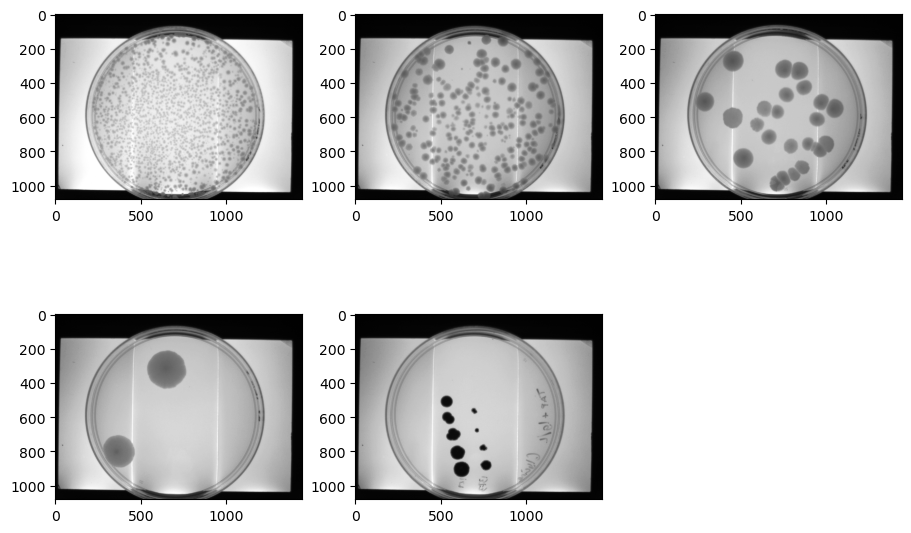

In [2]:
# get file paths to phenotype-o-mat image data
input_directory = Path(
    "/Users/ryanlane/Projects/2024-segment-colonies/data/phenotype-o-mat/2024-09-16"
)
jpg_filepaths = natsorted(input_directory.glob("*.jpg"))

# preview images
ncols = 3
nrows = int(np.ceil(len(jpg_filepaths) / 3))
fig, axes = plt.subplots(
    ncols=ncols,
    nrows=nrows,
    layout="constrained",
    figsize=(3 * ncols, 3 * nrows)
)

for i, jpg_filepath in enumerate(jpg_filepaths):
    # load image
    image = ski.io.imread(jpg_filepath)

    # plot
    ax = axes.flat[i]
    ax.imshow(image, cmap="Greys_r")

[fig.delaxes(axes.flat[i]) for i in range(len(jpg_filepaths), ncols * nrows)];

  0%|          | 0/5 [00:00<?, ?it/s]

[525]
(array([0.52620968]), array([699]), array([590]), array([525]))
[525]
(array([0.44354839]), array([698]), array([589]), array([525]))
[525]
(array([0.60719086]), array([711]), array([587]), array([525]))
[525]
(array([0.4905914]), array([698]), array([589]), array([525]))
[525]
(array([0.42372312]), array([698]), array([592]), array([525]))


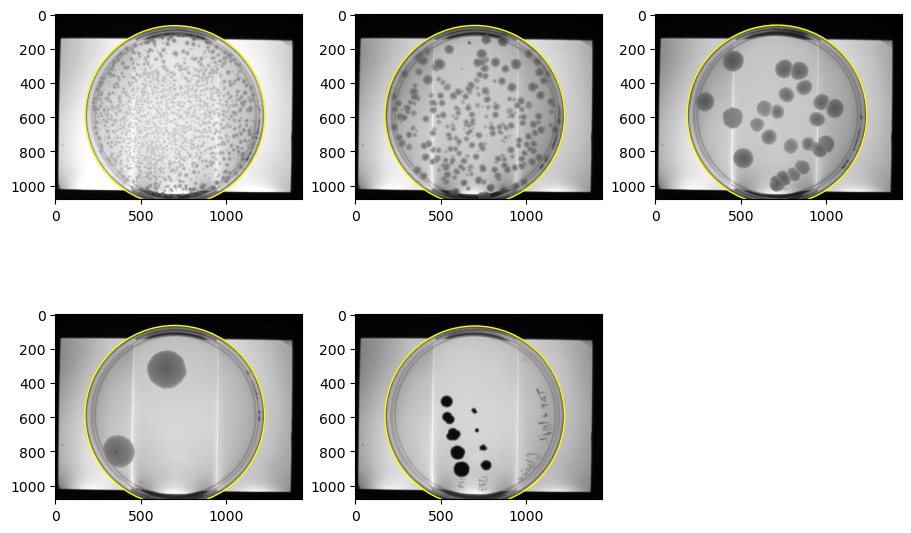

In [3]:
# preview images
ncols = 3
nrows = int(np.ceil(len(jpg_filepaths) / 3))
fig, axes = plt.subplots(
    ncols=ncols,
    nrows=nrows,
    layout="constrained",
    figsize=(3 * ncols, 3 * nrows)
)

for i, jpg_filepath in tqdm(enumerate(jpg_filepaths), total=len(jpg_filepaths)):
    # load image
    image = ski.io.imread(jpg_filepath)

    # edge detection
    edges = ski.filters.sobel(image)
    # threshold
    threshold = ski.filters.threshold_otsu(edges)
    edges_binary = edges > threshold

    # detect circular plate
    plate_radius = 525  # px
    # hough_radii = range(
    #     round(plate_radius) - 5,
    #     round(plate_radius) + 6,
    #     5,
    # )
    hough_radii = [525]
    print(list(hough_radii))

    hspaces = ski.transform.hough_circle(edges_binary, hough_radii)
    hough_peaks = ski.transform.hough_circle_peaks(
        hspaces=hspaces,
        radii=hough_radii,
        total_num_peaks=1,
    )
    print(hough_peaks)

    centers = np.stack([hough_peaks[1], hough_peaks[2]]).T

    # plot
    ax = axes.flat[i]
    ax.imshow(image, cmap="Greys_r")

    for center in centers:
        patch = Circle(center, radius=plate_radius, facecolor="none", edgecolor="#ffff00")
        ax.add_patch(patch)

[fig.delaxes(axes.flat[i]) for i in range(len(jpg_filepaths), ncols * nrows)];

  0%|          | 0/5 [00:00<?, ?it/s]

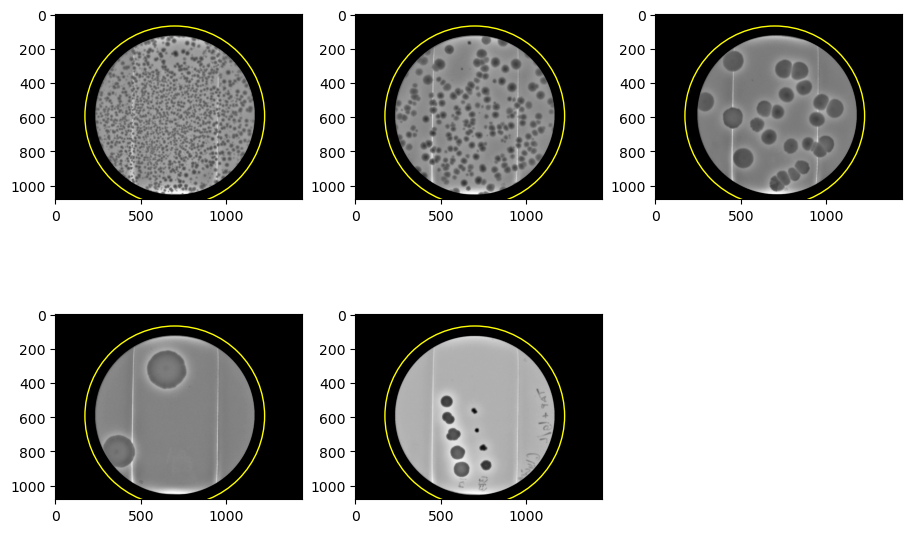

In [36]:
# preview images
ncols = 3
nrows = int(np.ceil(len(jpg_filepaths) / 3))
fig, axes = plt.subplots(
    ncols=ncols,
    nrows=nrows,
    layout="constrained",
    figsize=(3 * ncols, 3 * nrows)
)

for i, jpg_filepath in tqdm(enumerate(jpg_filepaths), total=len(jpg_filepaths)):
    # load image
    image = ski.io.imread(jpg_filepath)

    # edge detection
    edges = ski.filters.sobel(image)
    # threshold
    threshold = ski.filters.threshold_otsu(edges)
    edges_binary = edges > threshold

    # detect circular plate
    plate_radius = 525  # px
    hough_radii = [525]
    hspaces = ski.transform.hough_circle(edges_binary, hough_radii)
    hough_peaks = ski.transform.hough_circle_peaks(
        hspaces=hspaces,
        radii=hough_radii,
        total_num_peaks=1,
    )
    center = hough_peaks[1], hough_peaks[2]
    radius = hough_peaks[3][0]

    # difference of Gaussians filter
    sigma_low, sigma_high = (1, 32)
    image_dog = ski.filters.difference_of_gaussians(image, sigma_low, sigma_high)
    # convert to int to allow for masking trick
    image_dog = ski.exposure.rescale_intensity(
        image_dog, out_range=np.ubyte
    )

    # clear everything outside plate
    Y, X = np.ogrid[:image.shape[0], :image.shape[1]]
    distance_from_center = np.sqrt((X - center[0])**2 + (Y - center[1])**2)
    mask = distance_from_center <= radius - 60
    masked_image = np.zeros_like(image)
    # masked_image[mask] = image[mask]
    masked_image[mask] = image_dog[mask]

    # threshold
    threshold = ski.filters.threshold_otsu(image_dog)
    # thing = ski.util.invert(masked_image)
    image_segmented = masked_image < threshold

    # plot
    ax = axes.flat[i]
    ax.imshow(masked_image, cmap="Greys_r")

    for center in centers:
        patch = Circle(center, radius=plate_radius, facecolor="none", edgecolor="#ffff00")
        ax.add_patch(patch)

[fig.delaxes(axes.flat[i]) for i in range(len(jpg_filepaths), ncols * nrows)];

  0%|          | 0/5 [00:00<?, ?it/s]

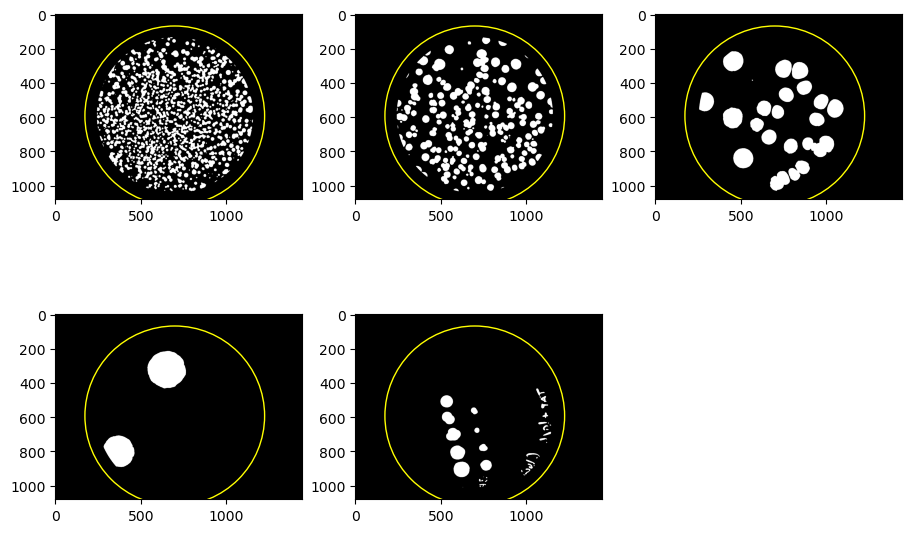

In [48]:
# preview images
ncols = 3
nrows = int(np.ceil(len(jpg_filepaths) / 3))
fig, axes = plt.subplots(
    ncols=ncols,
    nrows=nrows,
    layout="constrained",
    figsize=(3 * ncols, 3 * nrows)
)

for i, jpg_filepath in tqdm(enumerate(jpg_filepaths), total=len(jpg_filepaths)):
    # load image
    image = ski.io.imread(jpg_filepath)

    # edge detection
    edges = ski.filters.sobel(image)
    # threshold
    threshold = ski.filters.threshold_otsu(edges)
    edges_binary = edges > threshold

    # detect circular plate
    plate_radius = 525  # px
    hough_radii = [525]
    hspaces = ski.transform.hough_circle(edges_binary, hough_radii)
    hough_peaks = ski.transform.hough_circle_peaks(
        hspaces=hspaces,
        radii=hough_radii,
        total_num_peaks=1,
    )
    center = hough_peaks[1], hough_peaks[2]
    radius = hough_peaks[3][0]

    # difference of Gaussians filter
    sigma_low, sigma_high = (1.6, 48)
    image_dog = ski.filters.difference_of_gaussians(image, sigma_low, sigma_high)

    # threshold
    threshold = ski.filters.threshold_otsu(image_dog)
    image_segmented = image_dog < threshold

    # clear everything outside plate
    Y, X = np.ogrid[:image.shape[0], :image.shape[1]]
    distance_from_center = np.sqrt((X - center[0])**2 + (Y - center[1])**2)
    mask = distance_from_center <= radius - 70
    masked_image = np.zeros_like(image)
    masked_image[mask] = image_segmented[mask]

    # plot
    ax = axes.flat[i]
    ax.imshow(masked_image, cmap="Greys_r")

    for center in centers:
        patch = Circle(center, radius=plate_radius, facecolor="none", edgecolor="#ffff00")
        ax.add_patch(patch)

[fig.delaxes(axes.flat[i]) for i in range(len(jpg_filepaths), ncols * nrows)];

  0%|          | 0/5 [00:00<?, ?it/s]

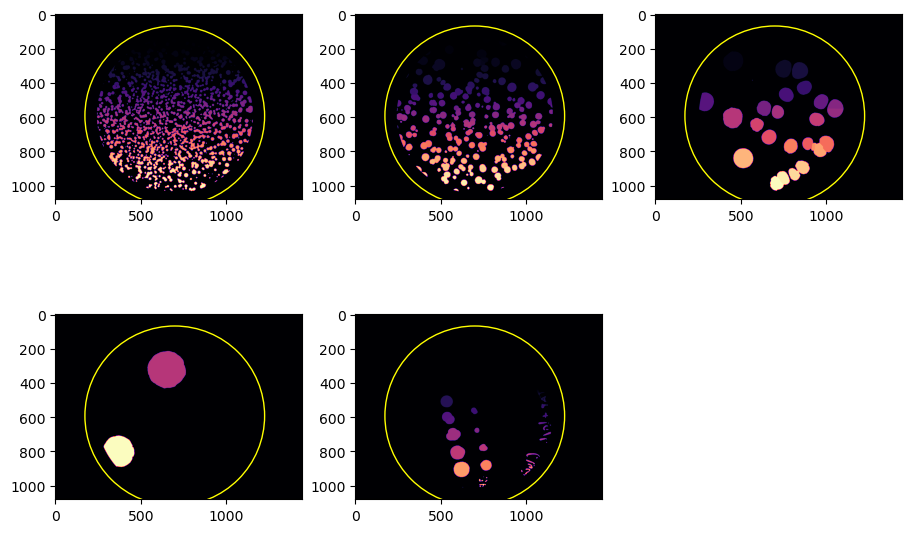

In [76]:
# preview images
ncols = 3
nrows = int(np.ceil(len(jpg_filepaths) / 3))
fig, axes = plt.subplots(
    ncols=ncols,
    nrows=nrows,
    layout="constrained",
    figsize=(3 * ncols, 3 * nrows)
)

for i, jpg_filepath in tqdm(enumerate(jpg_filepaths), total=len(jpg_filepaths)):
    # load image
    image = ski.io.imread(jpg_filepath)

    # edge detection
    edges = ski.filters.sobel(image)
    # threshold
    threshold = ski.filters.threshold_otsu(edges)
    edges_binary = edges > threshold

    # detect circular plate
    plate_radius = 525  # px
    hough_radii = [525]
    hspaces = ski.transform.hough_circle(edges_binary, hough_radii)
    hough_peaks = ski.transform.hough_circle_peaks(
        hspaces=hspaces,
        radii=hough_radii,
        total_num_peaks=1,
    )
    center = hough_peaks[1], hough_peaks[2]
    radius = hough_peaks[3][0]

    # difference of Gaussians filter
    sigma_low, sigma_high = (1.6, 48)
    image_dog = ski.filters.difference_of_gaussians(image, sigma_low, sigma_high)

    # threshold
    threshold = ski.filters.threshold_otsu(image_dog)
    image_segmented = image_dog < threshold

    # clear everything outside plate
    Y, X = np.ogrid[:image.shape[0], :image.shape[1]]
    distance_from_center = np.sqrt((X - center[0])**2 + (Y - center[1])**2)
    mask = distance_from_center <= radius - 70
    masked_image = np.zeros_like(image)
    masked_image[mask] = image_segmented[mask]

    # watershed
    # distance = distance_transform_edt(masked_image)
    # local_maxi = ski.morphology.local_maxima(distance)
    # markers = ski.measure.label(local_maxi)
    # labels = ski.segmentation.watershed(-distance, markers, mask=masked_image)

    # # watershed
    distance = distance_transform_edt(masked_image)
    # coords = ski.feature.peak_local_max(distance, footprint=np.ones((3, 3)), labels=masked_image)
    coords = ski.feature.peak_local_max(distance, footprint=np.ones((8, 8)), labels=masked_image)
    mask = np.zeros(distance.shape, dtype=bool)
    mask[tuple(coords.T)] = True
    markers = ski.measure.label(mask)
    labels = ski.segmentation.watershed(-distance, markers, mask=masked_image)

    # plot
    ax = axes.flat[i]
    # ax.imshow(distance, cmap="Greys_r")
    ax.imshow(labels, cmap="magma")
    # ax.plot(coords[:, 1], coords[:, 0], "+", color="#ffff00")

    for center in centers:
        patch = Circle(center, radius=plate_radius, facecolor="none", edgecolor="#ffff00")
        ax.add_patch(patch)

[fig.delaxes(axes.flat[i]) for i in range(len(jpg_filepaths), ncols * nrows)];

  0%|          | 0/5 [00:00<?, ?it/s]

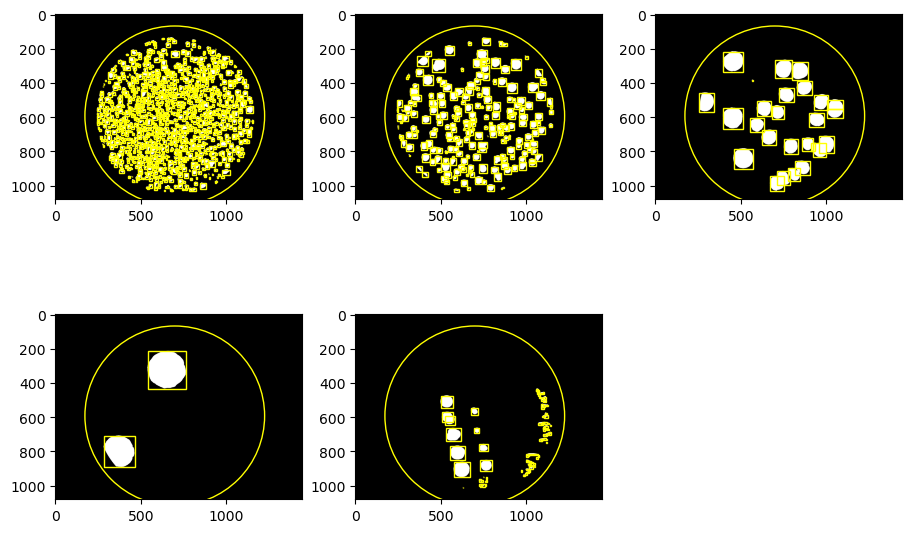

In [80]:
# preview images
ncols = 3
nrows = int(np.ceil(len(jpg_filepaths) / 3))
fig, axes = plt.subplots(
    ncols=ncols,
    nrows=nrows,
    layout="constrained",
    figsize=(3 * ncols, 3 * nrows)
)

for i, jpg_filepath in tqdm(enumerate(jpg_filepaths), total=len(jpg_filepaths)):
    # load image
    image = ski.io.imread(jpg_filepath)

    # edge detection
    edges = ski.filters.sobel(image)
    # threshold
    threshold = ski.filters.threshold_otsu(edges)
    edges_binary = edges > threshold

    # detect circular plate
    plate_radius = 525  # px
    hough_radii = [525]
    hspaces = ski.transform.hough_circle(edges_binary, hough_radii)
    hough_peaks = ski.transform.hough_circle_peaks(
        hspaces=hspaces,
        radii=hough_radii,
        total_num_peaks=1,
    )
    center = hough_peaks[1], hough_peaks[2]
    radius = hough_peaks[3][0]

    # difference of Gaussians filter
    sigma_low, sigma_high = (1.6, 48)
    image_dog = ski.filters.difference_of_gaussians(image, sigma_low, sigma_high)

    # threshold
    threshold = ski.filters.threshold_otsu(image_dog)
    image_segmented = image_dog < threshold

    # clear everything outside plate
    Y, X = np.ogrid[:image.shape[0], :image.shape[1]]
    distance_from_center = np.sqrt((X - center[0])**2 + (Y - center[1])**2)
    mask = distance_from_center <= radius - 70
    masked_image = np.zeros_like(image)
    masked_image[mask] = image_segmented[mask]

    # watershed
    # distance = distance_transform_edt(masked_image)
    # local_maxi = ski.morphology.local_maxima(distance)
    # markers = ski.measure.label(local_maxi)
    # labels = ski.segmentation.watershed(-distance, markers, mask=masked_image)

    # watershed
    distance = distance_transform_edt(masked_image)
    # coords = ski.feature.peak_local_max(distance, footprint=np.ones((3, 3)), labels=masked_image)
    coords = ski.feature.peak_local_max(distance, footprint=np.ones((8, 8)), labels=masked_image)
    mask = np.zeros(distance.shape, dtype=bool)
    mask[tuple(coords.T)] = True
    markers = ski.measure.label(mask)
    labels = ski.segmentation.watershed(-distance, markers, mask=masked_image)

    # plot
    ax = axes.flat[i]
    # ax.imshow(distance, cmap="Greys_r")
    # ax.imshow(labels, cmap="magma")
    ax.imshow(labels > 0, cmap="Greys_r")
    # ax.plot(coords[:, 1], coords[:, 0], "+", color="#ffff00")

    for segment in ski.measure.regionprops(labels):
        anchor = segment.bbox[1], segment.bbox[0]
        width = segment.bbox[3] - segment.bbox[1]
        height = segment.bbox[2] - segment.bbox[0]
        patch = Rectangle(anchor, width, height, facecolor="none", edgecolor="#ffff00")
        ax.add_patch(patch)

    for center in centers:
        patch = Circle(center, radius=plate_radius, facecolor="none", edgecolor="#ffff00")
        ax.add_patch(patch)

[fig.delaxes(axes.flat[i]) for i in range(len(jpg_filepaths), ncols * nrows)];